In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
file_path = "Day18_19_student_habits_performance.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
print("Data Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe(include="all").T)

Data Types:


,Data Type
student_id,str
age,int64
gender,str
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,str
attendance_percentage,float64
sleep_hours,float64
diet_quality,str



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 no

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
duplicates = df.duplicated().sum()

print("Missing Values:")
display(missing[missing > 0].to_frame("Missing Count") if (missing > 0).any()
        else pd.DataFrame({"Message": ["No missing values found"]}))

print(f"\nDuplicate Rows: {duplicates}")

Missing Values:


,Missing Count
parental_education_level,91



Duplicate Rows: 0


In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Variables:")
print(numerical_cols)

print("\nCategorical Variables:")
print(categorical_cols)

Numerical Variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical Variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


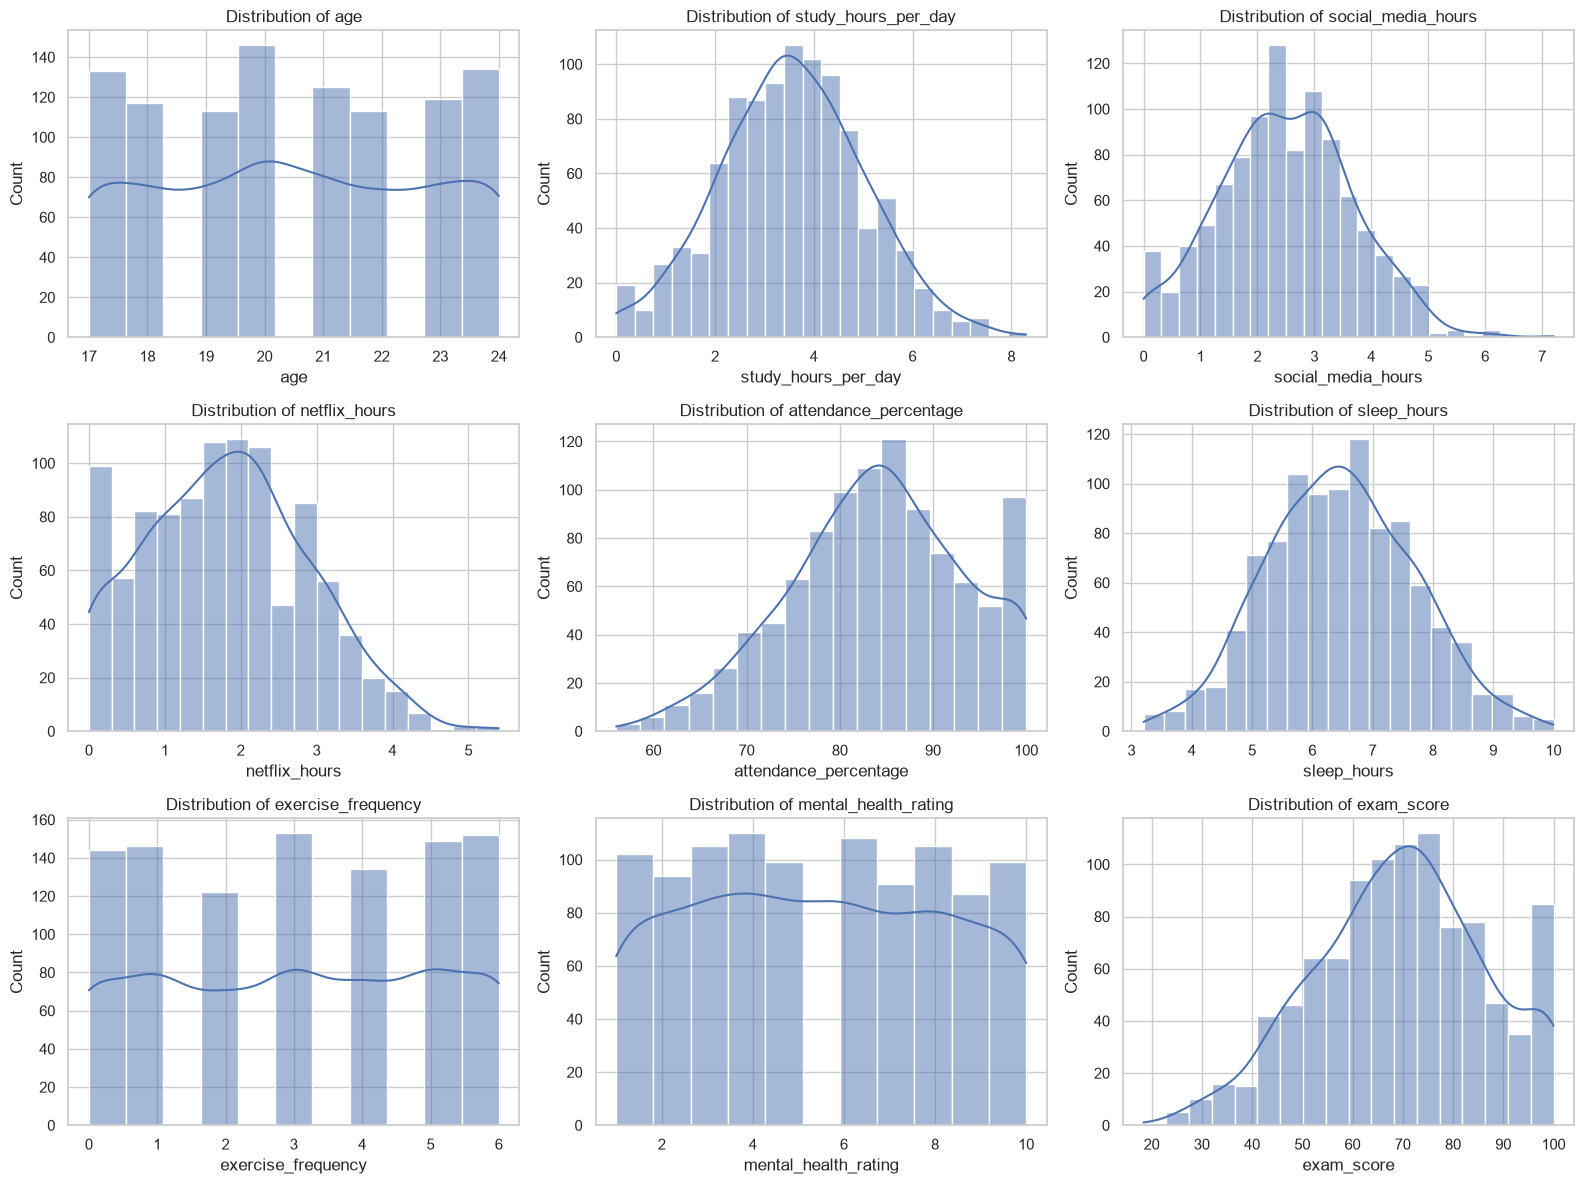

In [6]:
plot_cols = numerical_cols
ncols = 3
nrows = int(np.ceil(len(plot_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, plot_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

for ax in axes[len(plot_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

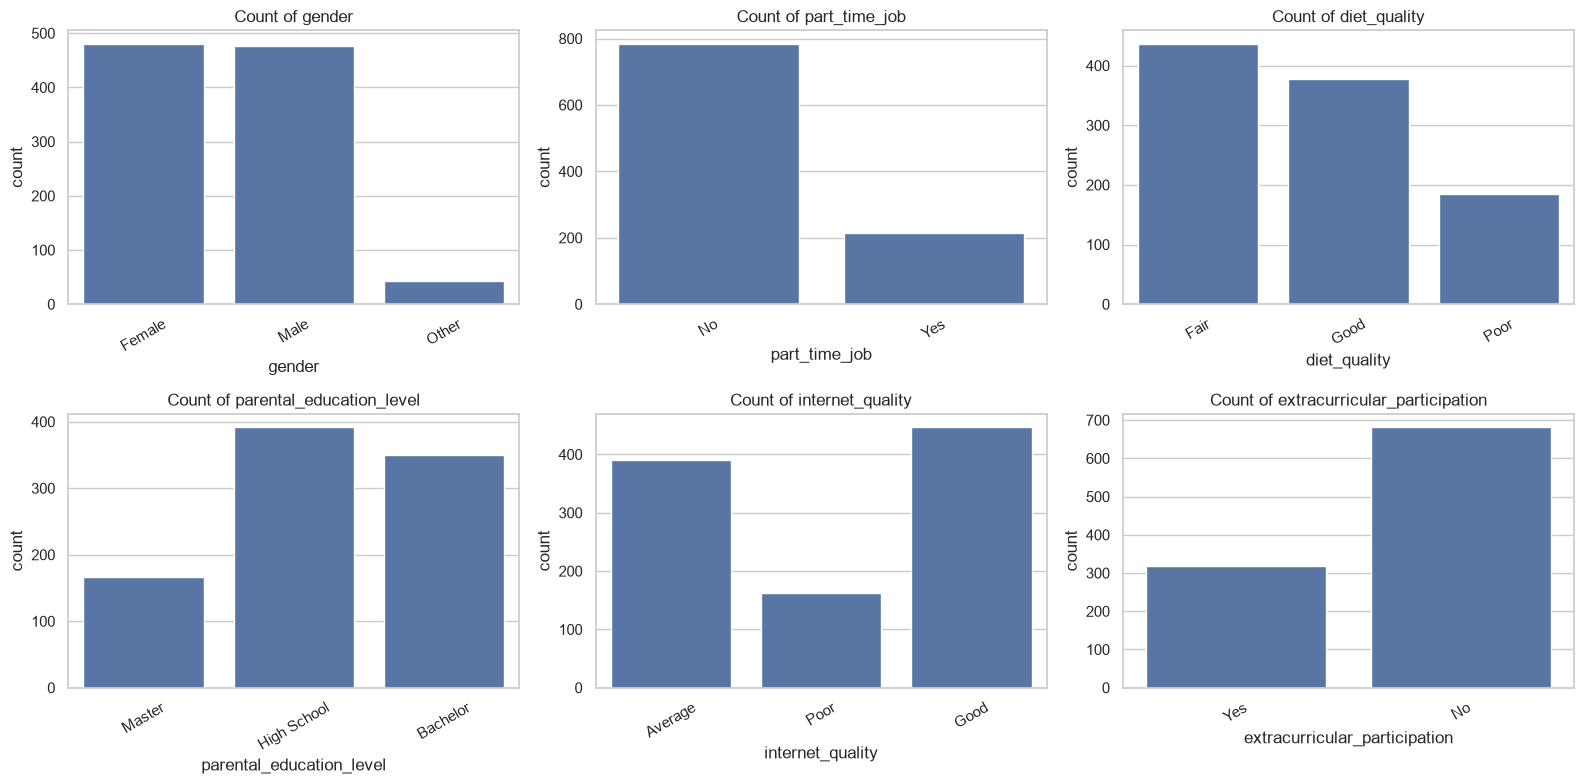

In [7]:
eda_categorical = [c for c in categorical_cols if df[c].nunique() < 20]

ncols = 3
nrows = int(np.ceil(len(eda_categorical) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, eda_categorical):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Count of {col}")
    ax.tick_params(axis='x', rotation=30)

for ax in axes[len(eda_categorical):]:
    ax.remove()

plt.tight_layout()
plt.show()

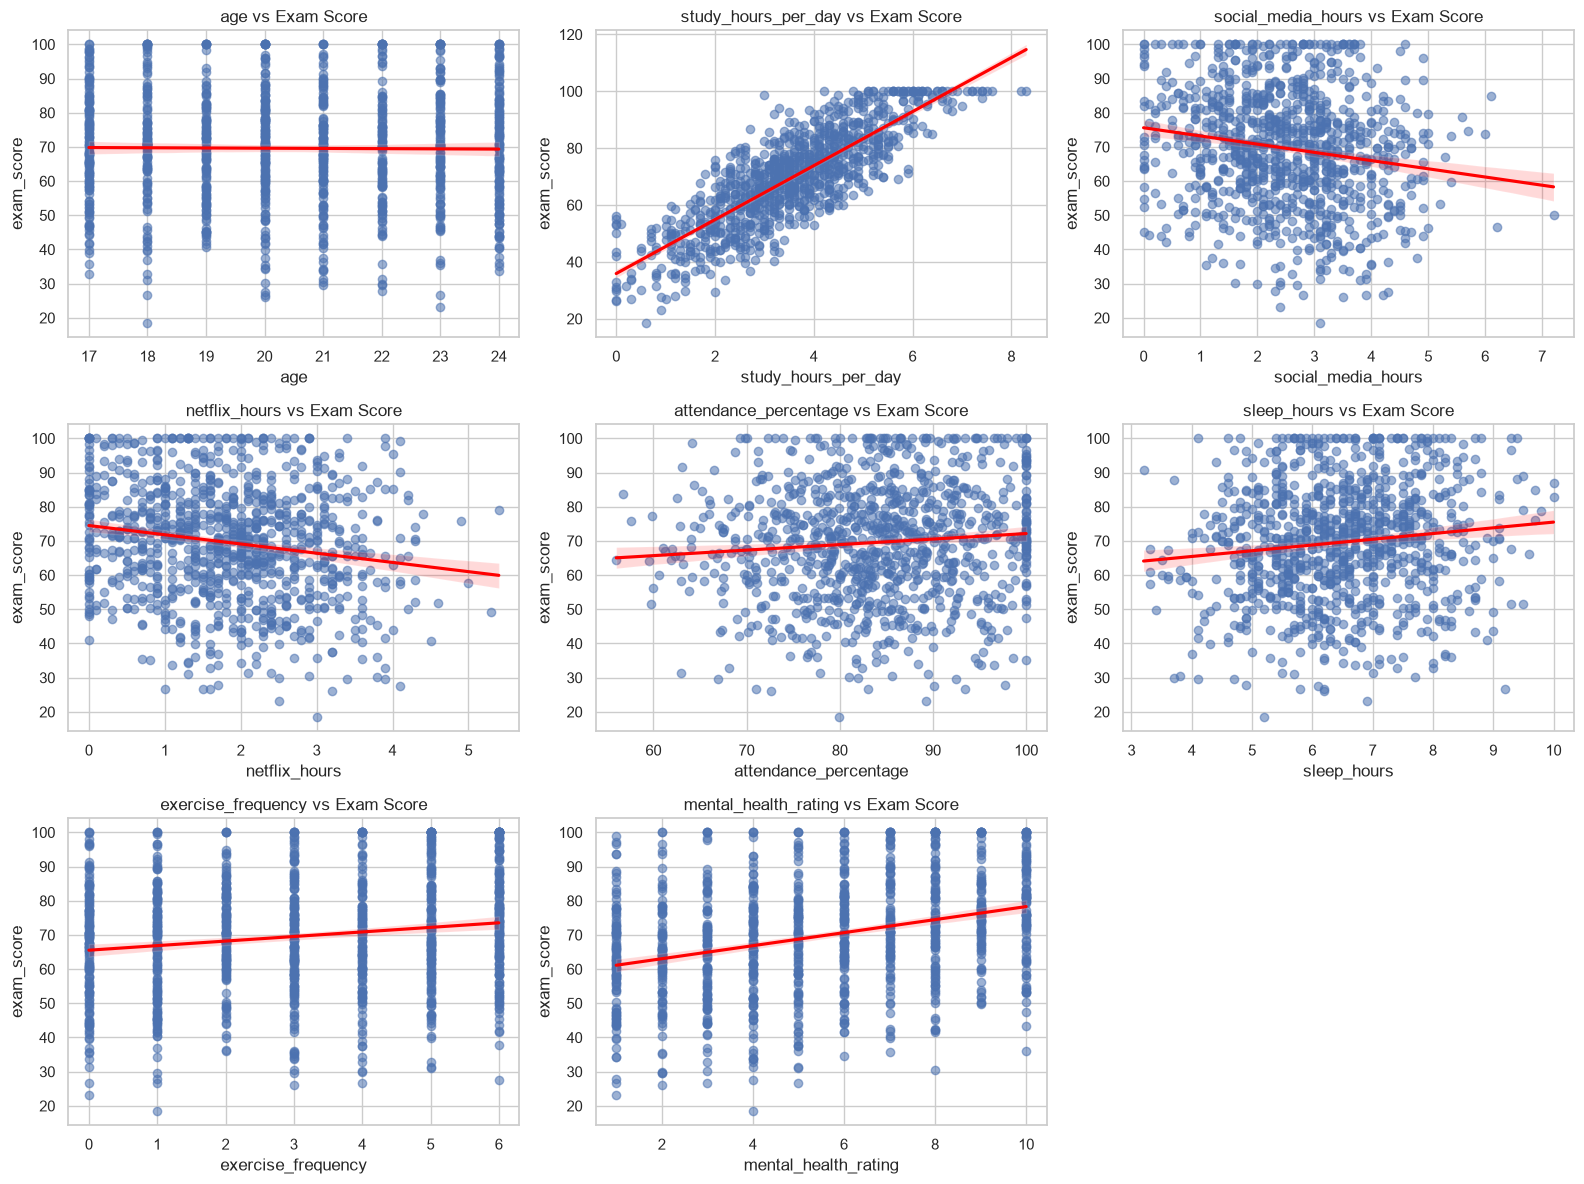

In [8]:
feature_cols_numeric = [c for c in numerical_cols if c != "exam_score"]

ncols = 3
nrows = int(np.ceil(len(feature_cols_numeric) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, feature_cols_numeric):
    sns.regplot(data=df, x=col, y="exam_score",
                scatter_kws={"alpha": 0.55}, line_kws={"color": "red"}, ax=ax)
    ax.set_title(f"{col} vs Exam Score")

for ax in axes[len(feature_cols_numeric):]:
    ax.remove()

plt.tight_layout()
plt.show()

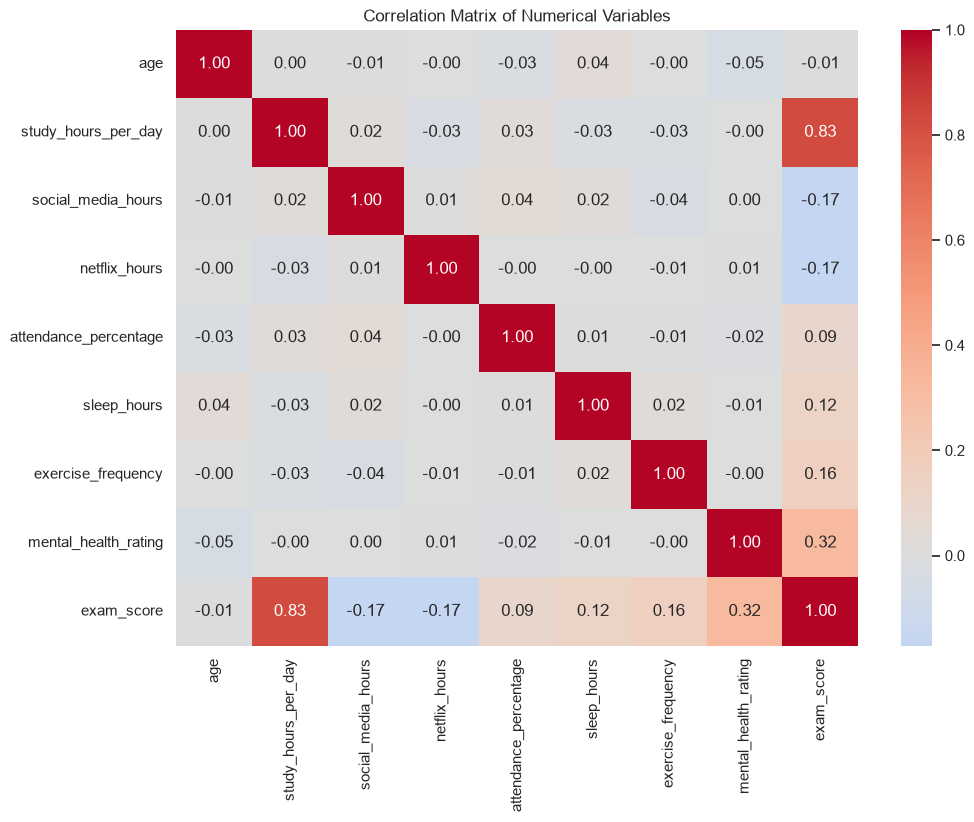

Numerical Feature Correlations with Exam Score:


,Correlation with exam_score
study_hours_per_day,0.825419
mental_health_rating,0.321523
netflix_hours,-0.171779
social_media_hours,-0.166733
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907


In [9]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

target_corr = corr["exam_score"].drop("exam_score").sort_values(key=np.abs, ascending=False)
print("Numerical Feature Correlations with Exam Score:")
display(target_corr.to_frame("Correlation with exam_score"))


Exam Score by gender:


,mean,median,count
gender,,,
Other,70.647619,69.0,42
Female,69.741372,70.7,481
Male,69.368344,70.2,477


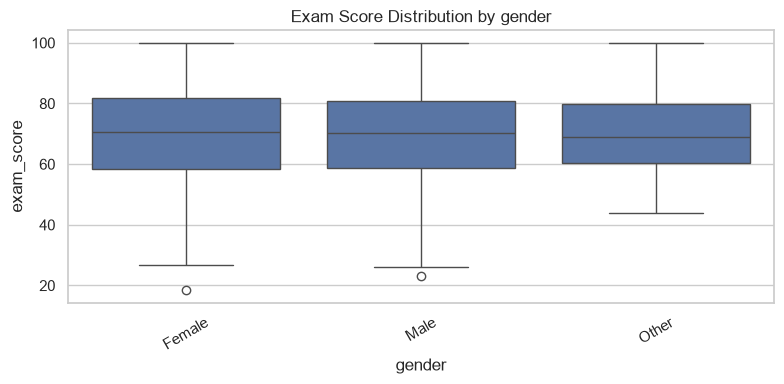


Exam Score by part_time_job:


,mean,median,count
part_time_job,,,
No,69.836561,70.6,785
Yes,68.743256,69.2,215


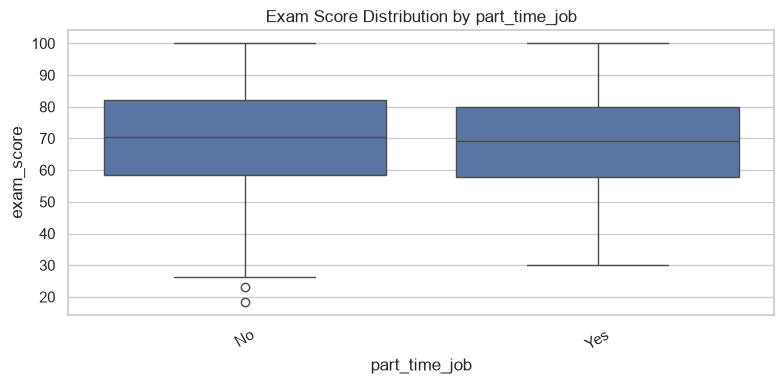


Exam Score by diet_quality:


,mean,median,count
diet_quality,,,
Fair,70.428833,71.0,437
Good,69.366402,70.3,378
Poor,68.127568,67.4,185


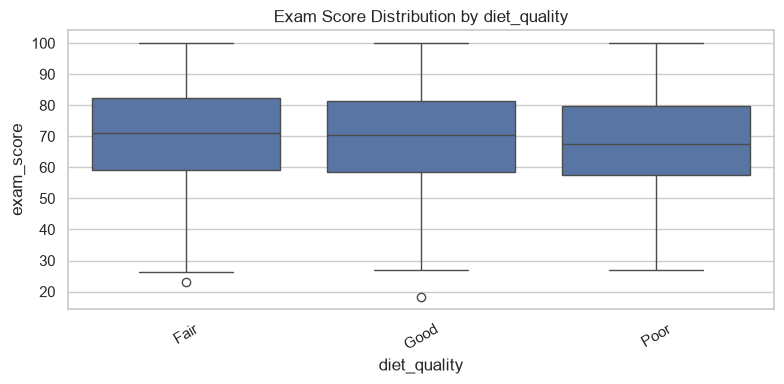


Exam Score by parental_education_level:


,mean,median,count
parental_education_level,,,
Bachelor,70.272571,71.70,350
High School,69.547194,69.95,392
Master,68.086826,66.80,167


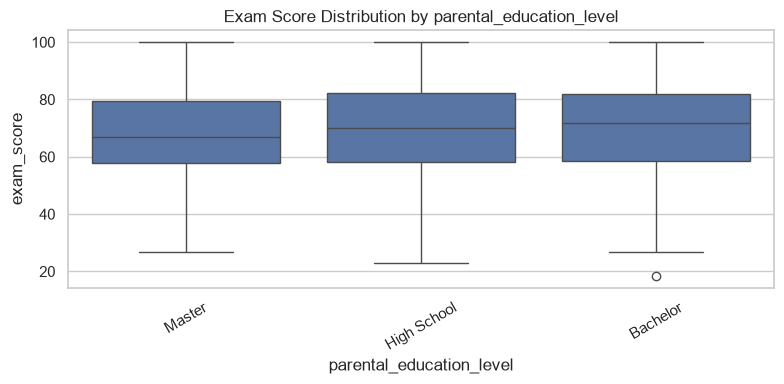


Exam Score by internet_quality:


,mean,median,count
internet_quality,,,
Average,70.643990,71.0,391
Poor,69.717284,71.4,162
Good,68.647651,69.3,447


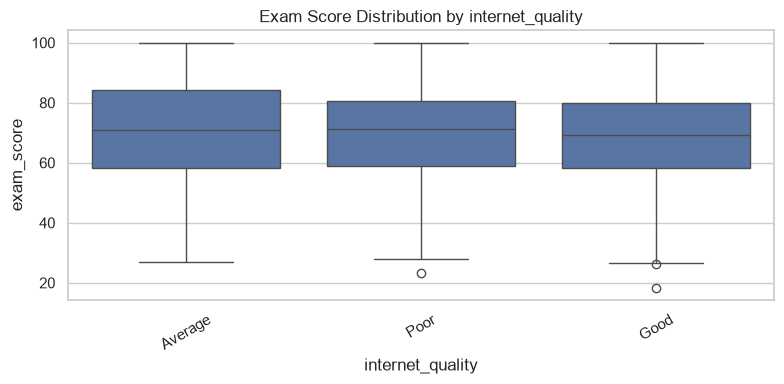


Exam Score by extracurricular_participation:


,mean,median,count
extracurricular_participation,,,
Yes,69.623270,70.65,318
No,69.591349,70.35,682


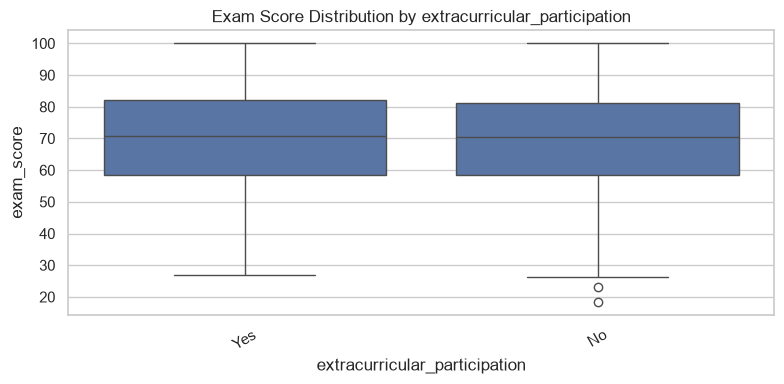

In [10]:
for col in eda_categorical:
    if col != "student_id":
        summary = df.groupby(col)["exam_score"].agg(["mean", "median", "count"]).sort_values("mean", ascending=False)
        print(f"\nExam Score by {col}:")
        display(summary)

        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x=col, y="exam_score")
        plt.title(f"Exam Score Distribution by {col}")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
1,study_hours_per_day,2.600,4.500,1.900,-0.2500,7.3500,7
2,social_media_hours,1.700,3.300,1.600,-0.7000,5.7000,5
3,netflix_hours,1.000,2.525,1.525,-1.2875,4.8125,4
4,attendance_percentage,78.000,91.025,13.025,58.4625,110.5625,3
5,sleep_hours,5.600,7.300,1.700,3.0500,9.8500,2
8,exam_score,58.475,81.325,22.850,24.2000,115.6000,2
0,age,18.750,23.000,4.250,12.3750,29.3750,0
6,exercise_frequency,1.000,5.000,4.000,-5.0000,11.0000,0
7,mental_health_rating,3.000,8.000,5.000,-4.5000,15.5000,0


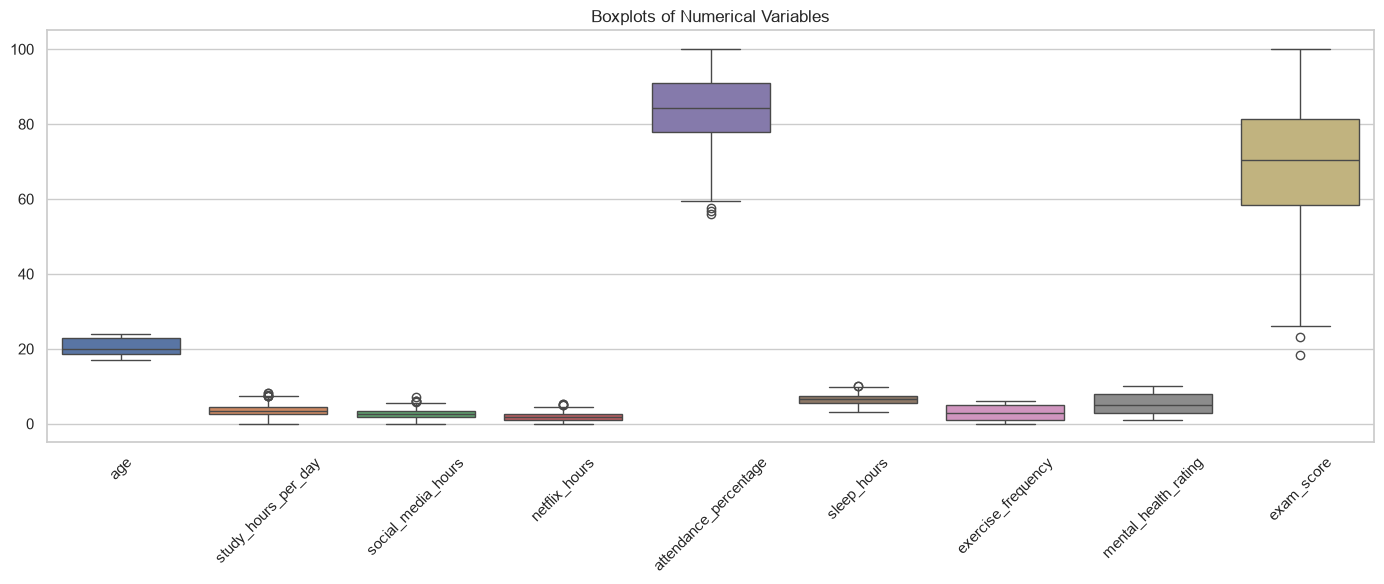

In [11]:
outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, Q1, Q3, IQR, lower, upper, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Variable", "Q1", "Q3", "IQR", "Lower Bound", "Upper Bound", "Potential Outliers"]
)

display(outlier_df.sort_values("Potential Outliers", ascending=False))

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Variables")
plt.tight_layout()
plt.show()

In [12]:
target_regression = "exam_score"

# Drop identifier column
X = df.drop(columns=[target_regression, "student_id"], errors="ignore").copy()
y_reg = df[target_regression].copy()

# Identify feature types after removing target and identifier
num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features Used:", num_features)
print("Categorical Features Used:", cat_features)
print("\nTarget: exam_score")

Numerical Features Used: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical Features Used: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']

Target: exam_score


In [13]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

In [14]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.20, random_state=42
)

print("Regression Training Shape:", X_train_reg.shape)
print("Regression Testing Shape:", X_test_reg.shape)

Regression Training Shape: (800, 14)
Regression Testing Shape: (200, 14)


In [15]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train_reg, y_train_reg)

y_train_pred_reg = linear_model.predict(X_train_reg)
y_test_pred_reg = linear_model.predict(X_test_reg)

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R² Score": r2_score(y_true, y_pred)
    }

reg_train_metrics = regression_metrics(y_train_reg, y_train_pred_reg)
reg_test_metrics = regression_metrics(y_test_reg, y_test_pred_reg)

reg_results = pd.DataFrame(
    [reg_train_metrics, reg_test_metrics],
    index=["Training Data", "Testing Data"]
)

display(reg_results)

,MAE,MSE,RMSE,R² Score
Training Data,4.214166,28.566058,5.344722,0.902108
Testing Data,4.192343,26.532535,5.150974,0.896531


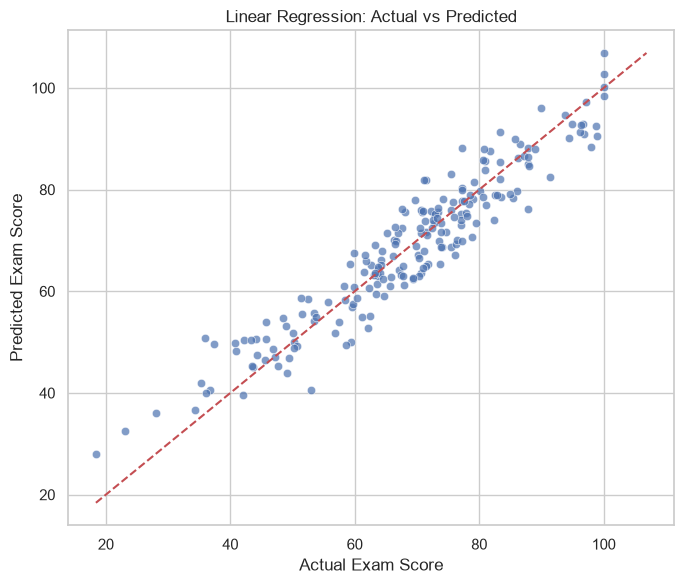

In [16]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test_reg, y=y_test_pred_reg, alpha=0.7)
min_val = min(y_test_reg.min(), y_test_pred_reg.min())
max_val = max(y_test_reg.max(), y_test_pred_reg.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

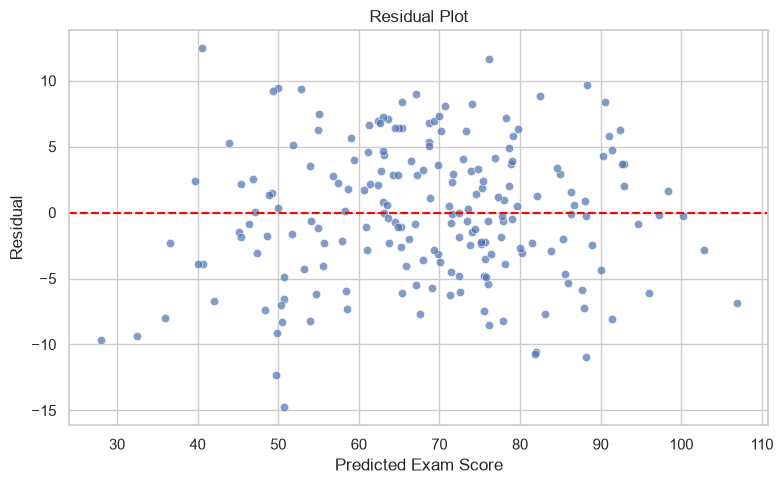

In [17]:
residuals = y_test_reg - y_test_pred_reg
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_pred_reg, y=residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()

Top features by absolute Linear Regression coefficient:


,Feature,Coefficient,Absolute Importance
1,num__study_hours_per_day,14.144790,14.144790
7,num__mental_health_rating,5.565088,5.565088
2,num__social_media_hours,-3.129732,3.129732
6,num__exercise_frequency,2.656671,2.656671
3,num__netflix_hours,-2.531563,2.531563
5,num__sleep_hours,2.421865,2.421865
4,num__attendance_percentage,1.349632,1.349632
13,cat__diet_quality_Fair,0.502625,0.502625
10,cat__gender_Other,0.491633,0.491633
14,cat__diet_quality_Good,-0.455348,0.455348


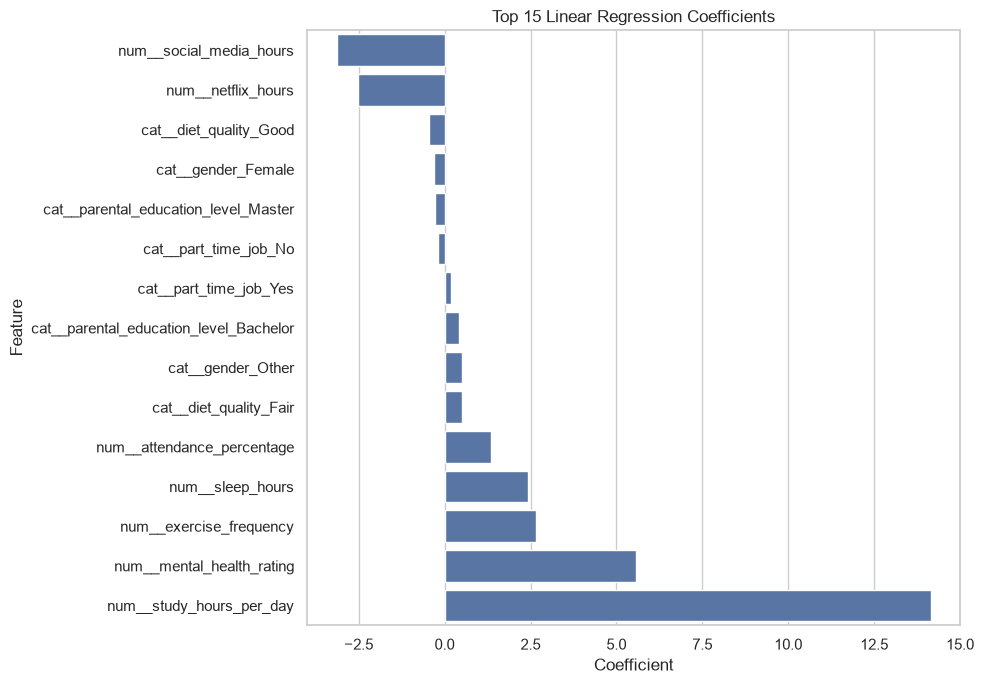

In [18]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute Importance": np.abs(coefficients)
}).sort_values("Absolute Importance", ascending=False)

print("Top features by absolute Linear Regression coefficient:")
display(coef_df.head(15))

plt.figure(figsize=(10, 7))
top_coef = coef_df.head(15).sort_values("Coefficient")
sns.barplot(data=top_coef, x="Coefficient", y="Feature")
plt.title("Top 15 Linear Regression Coefficients")
plt.tight_layout()
plt.show()

In [19]:
y_class = (df["exam_score"] >= 50).astype(int)

print("Class Distribution:")
class_distribution = y_class.value_counts().rename(index={0: "Fail", 1: "Pass"})
display(class_distribution.to_frame("Count"))

print("\nClass Percentages:")
display((y_class.value_counts(normalize=True) * 100).rename(index={0: "Fail", 1: "Pass"}).to_frame("Percentage"))

Class Distribution:


,Count
exam_score,
Pass,869
Fail,131



Class Percentages:


,Percentage
exam_score,
Pass,86.9
Fail,13.1


In [ ]:
# Train-test split for classification using stratification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

# Logistic Regression pipeline
classification_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

# Train model
classification_model.fit(X_train_cls, y_train_cls)

# Predictions
y_train_pred_cls = classification_model.predict(X_train_cls)
y_test_pred_cls = classification_model.predict(X_test_cls)